In [1]:
import matplotlib.pyplot as plt
from matplotlib import gridspec

from analysis import SimulationVisualizer
from environment import Environment
from voting_systems import (
    PluralityVoting,
)

In [2]:
NUM_VOTERS = 200
NUM_CANDIDATES = 6
NUM_PREFERENCES = 2
NUM_SIMULATIONS = 100
use_tom_flag = False
voting_system = PluralityVoting(use_theory_of_mind=use_tom_flag)
# voting_system = RankingVoting(use_theory_of_mind=use_tom_flag)
# voting_system = QuadraticVoting(use_theory_of_mind=use_tom_flag)
# voting_system = QuadraticVotingBudget(use_theory_of_mind=use_tom_flag)

env = Environment(
    num_voters=NUM_VOTERS,
    num_candidates=NUM_CANDIDATES,
    num_preferences=NUM_PREFERENCES,
    voting_system=voting_system,
    scenario=1,
    rounds=2,
    use_theory_of_mind=use_tom_flag,
)

Pre-compiling JAX function...
Compilation complete.


In [3]:
env.run(num_steps=NUM_SIMULATIONS)

Starting simulation...
--- Step 1/100 ---
--- Round 1 ---
Round 1 Results: {200: 32, 201: 46, 202: 19, 203: 4, 204: 17, 205: 82}
Finalists for Round 2: Candidates 205 and 201

--- Round 2 ---
Round 2 Results: {200: 0, 201: 75, 202: 0, 203: 0, 204: 0, 205: 125}
Final Winner is Candidate ID: 205.
--- Step 2/100 ---
--- Round 1 ---
Round 1 Results: {200: 33, 201: 55, 202: 18, 203: 5, 204: 22, 205: 67}
Finalists for Round 2: Candidates 205 and 201

--- Round 2 ---
Round 2 Results: {200: 0, 201: 87, 202: 0, 203: 0, 204: 0, 205: 113}
Final Winner is Candidate ID: 205.
--- Step 3/100 ---
--- Round 1 ---
Round 1 Results: {200: 39, 201: 38, 202: 15, 203: 6, 204: 29, 205: 73}
Finalists for Round 2: Candidates 205 and 200

--- Round 2 ---
Round 2 Results: {200: 64, 201: 0, 202: 0, 203: 0, 204: 0, 205: 136}
Final Winner is Candidate ID: 205.
--- Step 4/100 ---
--- Round 1 ---
Round 1 Results: {200: 28, 201: 46, 202: 17, 203: 3, 204: 19, 205: 87}
Finalists for Round 2: Candidates 205 and 201

--- R

In [4]:
# Create the visualizer instance as before
visualizer = SimulationVisualizer(env, env.datacollector)

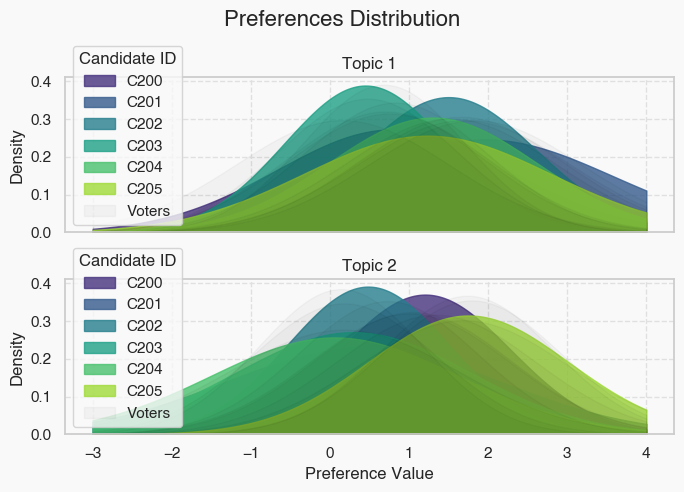

In [5]:
# 2. Create a figure and an array of axes.
fig, axes = plt.subplots(NUM_PREFERENCES, 1, figsize=(7, 5), sharex=True)
fig.suptitle("Preferences Distribution", fontsize=16)
fig, axes = visualizer.plot_preference_distributions(num_voters_to_show=10, axes=axes)
plt.show()
# fig.savefig("fig/distribution.png", dpi=300)

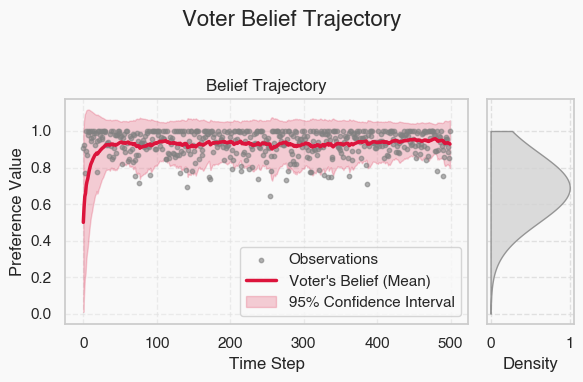

In [6]:
my_fig = plt.figure(figsize=(6, 4))
my_fig.suptitle("Voter Belief Trajectory", fontsize=16)
gs = gridspec.GridSpec(1, 5, figure=my_fig)
axes = my_fig.add_subplot(gs[0, 0:4])
density_ax = my_fig.add_subplot(gs[0, 4], sharey=axes)

# 2. Pass the axes tuple to your function
visualizer.plot_belief_trajectory(voter=env.agents[1], axes=(axes, density_ax))

# 3. You can continue to customize the figure
axes.set_title("Belief Trajectory")  # Override the default title
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout for suptitle
plt.show()
# my_fig.savefig("fig/voter_belief_trajectory.png", dpi=300)

# plot disatisfaction over time

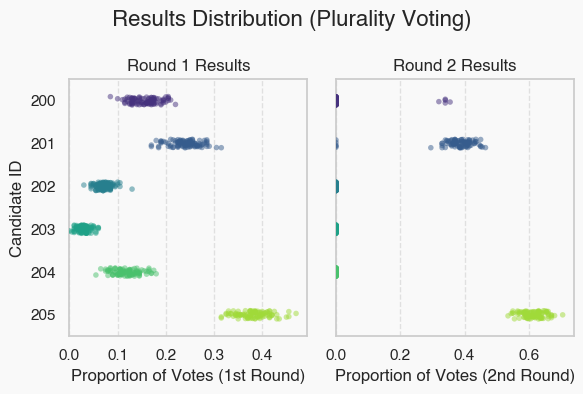

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(6, 4), sharey=True)
visualizer.plot_simulation_results_distribution(plot_kind="d", axes=axes)
# set titles for the entire figure and individual subplots
fig.suptitle(
    f"Results Distribution ({voting_system.name})",
    fontsize=16,
)
axes[0].set_xlabel("Proportion of Votes (1st Round)")
axes[1].set_xlabel("Proportion of Votes (2nd Round)")
plt.tight_layout()
plt.show()
# fig.savefig(f"fig/{voting_system.name}_simulation_results_distribution.png", dpi=300)

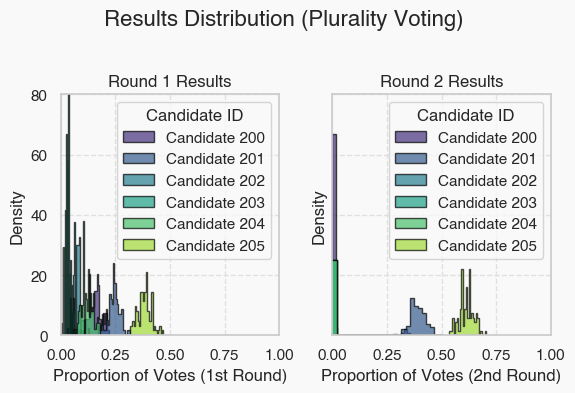

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(6, 4), sharey=True)
fig.suptitle(
    f"Results Distribution ({voting_system.name})",
    fontsize=16,
)
# y limits
# bins de la même taille
visualizer.plot_simulation_results_distribution(axes=axes)
axes[0].set_ylim(0, 80)
axes[1].set_ylim(0, 80)
axes[0].set_xlabel("Proportion of Votes (1st Round)")
axes[1].set_xlabel("Proportion of Votes (2nd Round)")
plt.show()
# fig.savefig(f"fig/{voting_system.name}_simulation_results_histogram.png", dpi=300)

# bar plot winner final result

# measure disatisfaction after election
